<img src="img/logoitqv1.jpg" width="500">
<br>

# 3_2_3_Image_segmentation

## 0.1 01PAO26-26 - Segmentación de imágenes
<br>

<img src="img/python_logo.png" width="300">
<br>

*Jesús Viera* https://github.com/Vierita23/machinelearning


In [1]:
import sys
import subprocess
from pathlib import Path

subprocess.run(
    [sys.executable, "-m", "pip", "install", "opencv-python", "matplotlib", "numpy", "scipy", "scikit-image", "-q"],
    check=False,
)

if not Path("images/figuras.png").exists():
    subprocess.run([sys.executable, "setup_segmentacion_images.py"], check=False)

print("Python:", sys.executable)


Python: C:\Users\Jesus\anaconda3\python.exe


### 0.0.1 SEGMENTACIÓN MEDIANTE THRESHOLDING


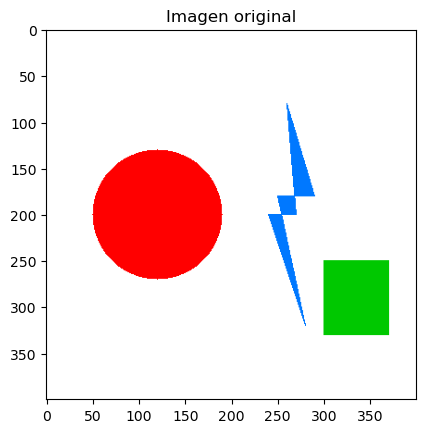

In [2]:
import matplotlib.pyplot as plt
import cv2

img = cv2.imread('images/figuras.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb, cmap='gray')
plt.title('Imagen original')
plt.show()


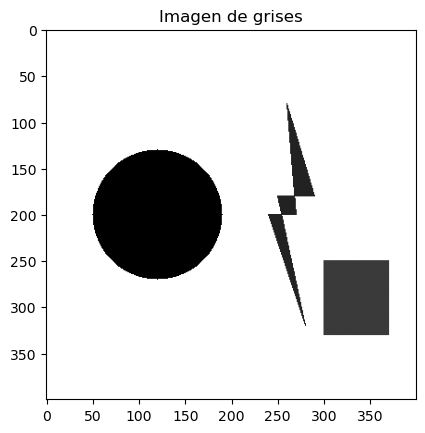

In [3]:
import numpy as np

gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray_img, cmap='gray')
plt.title('Imagen de grises')
plt.show()


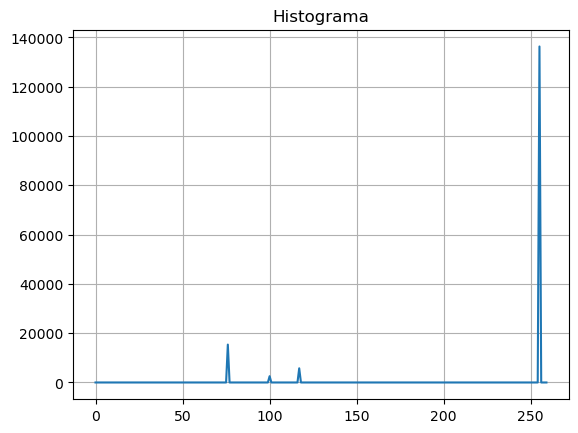

In [4]:
hist = cv2.calcHist([gray_img], [0], None, [260], [0, 260])
plt.plot(hist)
plt.grid()
plt.title('Histograma')
plt.show()


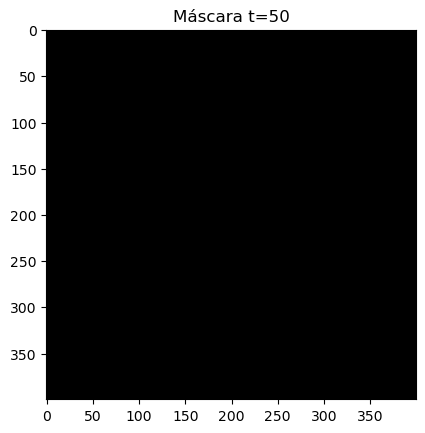

[255]


In [5]:
t = 50
maxim = 255
_, mask = cv2.threshold(gray_img, t, maxim, cv2.THRESH_BINARY)
plt.imshow(mask, cmap='gray')
plt.title('Máscara t=' + str(t))
plt.show()
print(np.unique(mask))


[0 1]


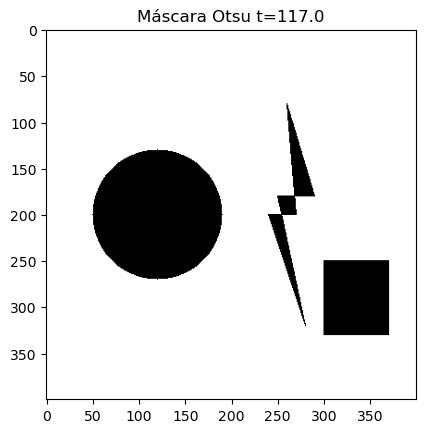

In [6]:
t, mask = cv2.threshold(gray_img, 0, 1, cv2.THRESH_OTSU)
print(np.unique(mask))
plt.imshow(mask, cmap='gray')
plt.title('Máscara Otsu t=' + str(t))
plt.show()


### 0.0.2 SEGMENTACIÓN MEDIANTE CONVERSIONES DE COLOR


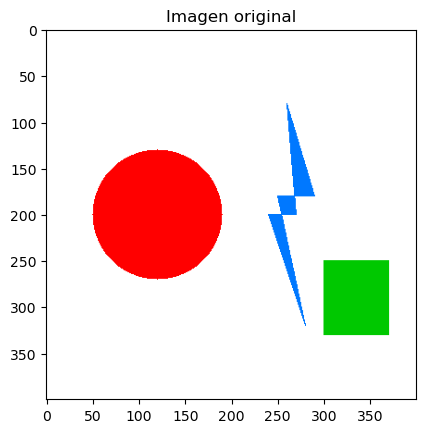

In [7]:
img = cv2.imread('images/images/figuras.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb, cmap='gray')
plt.title('Imagen original')
plt.show()


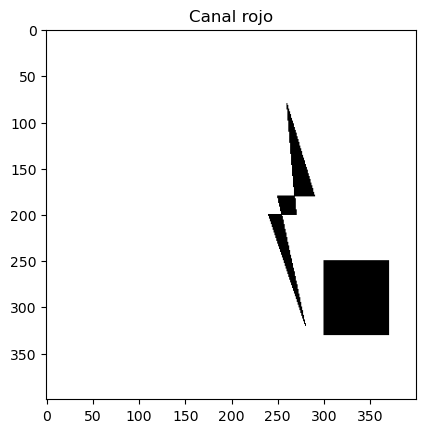

In [8]:
R = img[:, :, 2]
plt.imshow(R, cmap='gray')
plt.title('Canal rojo')
plt.show()


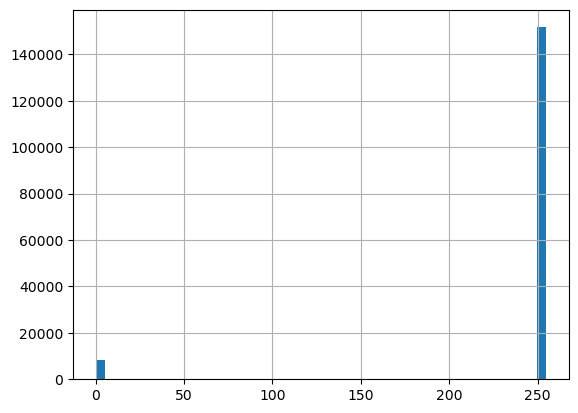

255


In [9]:
plt.hist(R.ravel(), bins=50)
plt.grid(True)
plt.show()
print(np.max(R))


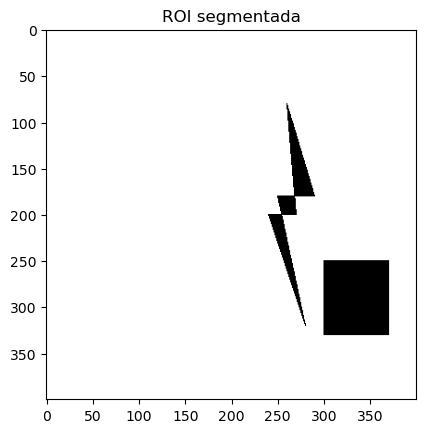

In [10]:
t = np.max(R)
mask = R.copy()
mask[mask < t] = 0
plt.imshow(mask, cmap='gray')
plt.title('ROI segmentada')
plt.show()


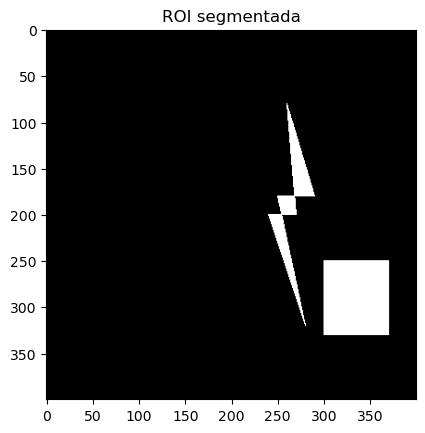

In [11]:
# Ejercicio individual
# Obtener máscara del rayo azul mediante segmentación por espacio de color

def convert_to_CMYK(rgb_p):
    with np.errstate(invalid='ignore', divide='ignore'):
        K = 1 - np.max(rgb_p, axis=2)
        C = (1 - rgb_p[:, :, 0] - K) / (1 - K)
        M = (1 - rgb_p[:, :, 1] - K) / (1 - K)
        Y = (1 - rgb_p[:, :, 2] - K) / (1 - K)
        CMYK = (np.dstack((C, M, Y, K)) * 255).astype('uint8')
    return CMYK

img = cv2.imread('images/figuras.png')
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
rgb_p = rgb.astype('uint8') / 255

CMYK = convert_to_CMYK(rgb_p)
C, M, Y, K = cv2.split(CMYK)
C = C.astype('uint8')

t = np.max(C)
mask = C.copy()
mask[mask < t] = 0

plt.imshow(C, cmap='gray')
plt.title('ROI segmentada')
plt.show()


### 0.0.3 SEGMENTACIÓN SEMÁNTICA CON DETECCIÓN DE BORDES


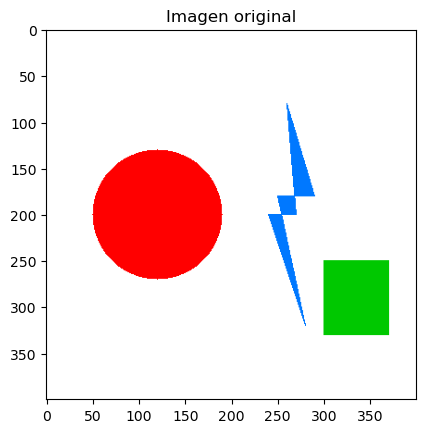

In [12]:
img = cv2.imread('images/images/figuras.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.title('Imagen original')
plt.show()


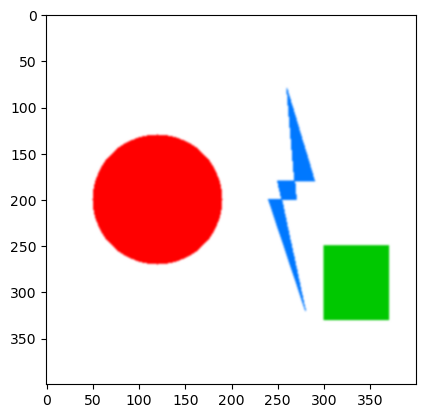

In [13]:
img_gaus = cv2.GaussianBlur(img_rgb, (5, 5), 0)
plt.imshow(img_gaus, cmap='gray')
plt.show()


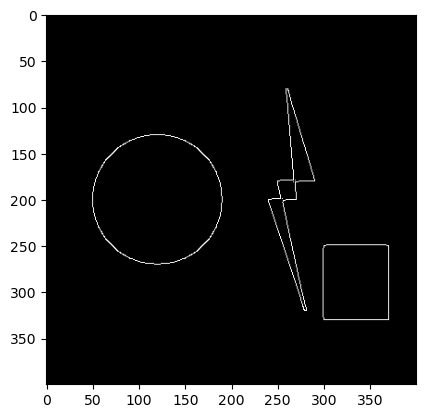

In [14]:
canny = cv2.Canny(img_gaus, 255 / 3, 255)
kernel = np.ones((2, 2), 'uint8')
# canny = cv2.dilate(canny, kernel, iterations=2)
# canny = cv2.erode(canny, kernel, iterations=2)
plt.imshow(canny, cmap='gray')
plt.show()


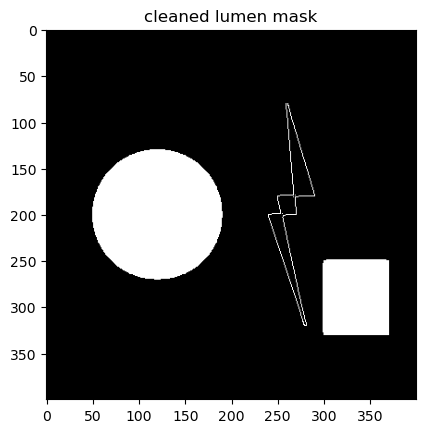

In [15]:
from scipy.ndimage import binary_fill_holes as bfh

bordes = canny.copy()
filled_bordes = bfh(bordes)
plt.imshow(filled_bordes.astype('uint8'), cmap='gray')
plt.title('cleaned lumen mask')
plt.show()


### 0.0.4 SEGMENTACIÓN POR CRECIMIENTO DE REGIONES (region growing)


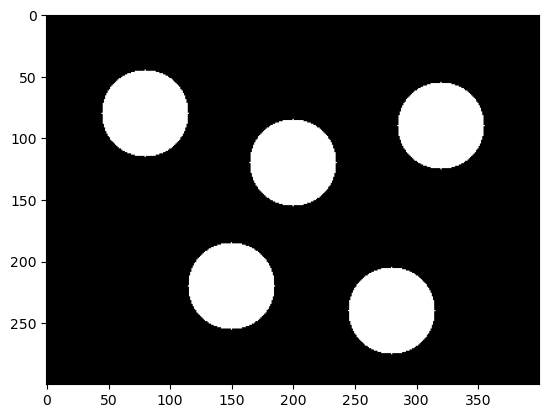

In [16]:
from skimage import io

img = cv2.imread('images/images/estrellas.png', 0)
plt.imshow(img, cmap='gray')
plt.show()


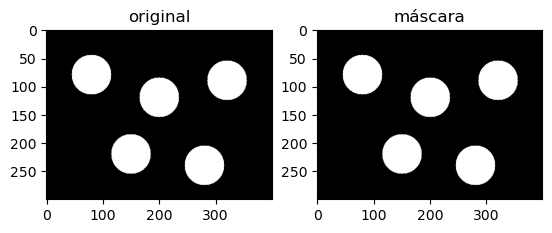

In [17]:
mask = img.copy()
h, w = img.shape
ref = np.zeros((h + 2, w + 2), np.uint8)
cv2.floodFill(mask, ref, (0, 0), 0)
fig, ax = plt.subplots(1, 2)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(mask, cmap='gray'), ax[1].set_title('máscara')
plt.show()
